# COE311K Final Project Part 2: Stiff ODEs
**Name:** Aditya Chokshi  
**EID:** aac6388  
**Date:** April 30, 2026  

## Section 1: Introduction & System Selection
In this project, I will use a **Mechanical System with High Damping (D)**. In real life, it is a "heave damper," which is one of the three components in the suspension of a racecar vehicle. The heave damper is extremely rigid to withstand large forces that may arise from strong downforce, ensuring that the floor of the racecar remains firmly attached to the track.

The governing first-order ODE for this overdamped system is:
dy/dt = -5000 * (y - 0.1 * sin(2t))

Where:
* y(t) = damper displacement (m)
* 5000 = lambda, the high damping rate (1/s)
* 0.1 * sin(2t) = the slowly varying external track profile (m)
* Initial condition: y(0) = 0.5 m

**The significance:** This is a very stiff system since the inner dynamics of the damper happen within 0.2 milliseconds (1/5000), while the outer dynamics of the track bumps happen within seconds. Simulating even one whole lap with a regular numerical method will be mathematically impossible due to the need for very small steps.

## Section 2: Demonstration of Stiffness
To demonstrate stiffness, we will calculate the stability limit of Euler's Forward method. 
For the equation dy/dt = -lambda * y, the stability region for Euler's Forward is:
|1 - h * lambda| <= 1
h <= 2 / lambda

With lambda = 5000, the maximum stable step size is:
h_max = 2 / 5000 = 0.0004 seconds.

**Quantitative Stiffness Analysis (Time Scale Ratio):**
* Fast time scale (transient response): t_fast = 1 / 5000 = 0.0002 s
* Slow time scale (forcing function): The frequency is 2 rad/s, so t_slow = 2π / 2 ≈ 3.14 s
* **Stiffness Ratio:** t_slow / t_fast = 3.14 / 0.0002 = 15,700

Because of this immense stiffness ratio of 15,700, explicit methods are computationally paralyzing. Simulating just 3 seconds of track driving requires at least 7,500 steps.

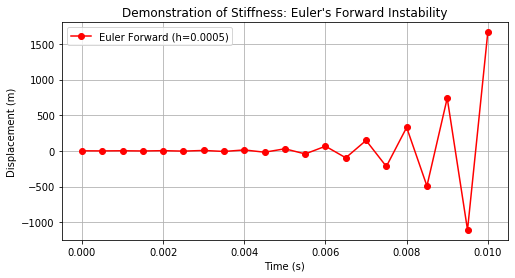

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- System Parameters ---
lam = 5000.0
y0 = 0.5
t_span = (0, 3.0)

def f_stiff(t, y):
    return -lam * (y - 0.1 * np.sin(2 * t))

# --- Demonstrate Euler's Forward Failure ---
def euler_forward(f, t_span, y0, h):
    t = np.arange(t_span[0], t_span[1] + h, h)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(len(t) - 1):
        y[i+1] = y[i] + h * f(t[i], y[i])
    return t, y

# Test with a step size that is "small" but theoretically unstable for this system
h_unstable = 0.0005 
t_fail, y_fail = euler_forward(f_stiff, (0, 0.01), y0, h_unstable)

plt.figure(figsize=(8, 4))
plt.plot(t_fail, y_fail, 'r-o', label=f"Euler Forward (h={h_unstable})")
plt.title("Demonstration of Stiffness: Euler's Forward Instability")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.grid(True)
plt.legend()
plt.show()

## Section 3: Mathematical Setup

To bypass the severe stability limits of explicit methods, we use **Euler's Backward Method**:
y_{n+1} = y_n + h * f(t_{n+1}, y_{n+1})

Because y_{n+1} appears inside the function f, we must solve for it iteratively using the **Newton-Raphson Method**. We define a residual function F(y_{n+1}) that equals zero when we find the correct value:
F(y_{n+1}) = y_{n+1} - y_n - h * f(t_{n+1}, y_{n+1})

Substituting our specific ODE into the residual function:
F(y_{n+1}) = y_{n+1} - y_n - h * [-5000 * (y_{n+1} - 0.1 * sin(2 * t_{n+1}))]

To run Newton-Raphson, we need the analytical derivative of this residual with respect to y_{n+1}:
F'(y_{n+1}) = 1 - h * (df/dy)
F'(y_{n+1}) = 1 - h * (-5000) = 1 + 5000 * h

The Newton-Raphson update step is then:
y_new = y_guess - F(y_guess) / F'(y_guess)

In [9]:
# --- Section 4: Implementation ---

def newton_raphson(y_guess, y_n, t_next, h, tol=1e-6, max_iter=20):
    """Solves for y_{n+1} using Newton-Raphson iteration."""
    y = y_guess
    
    # Analytical derivative F'(y) is constant for this specific linear ODE
    dF_dy = 1.0 + lam * h
    
    for iterations in range(1, max_iter + 1):
        # Calculate residual F(y)
        f_val = f_stiff(t_next, y)
        F_y = y - y_n - h * f_val  # FIXED: Restored the cut-off variable
        
        # Check convergence
        if abs(F_y) < tol:
            return y, iterations
            
        # Update guess
        y = y - F_y / dF_dy
        
    print(f"Warning: NR did not converge at t={t_next}")
    return y, max_iter

def euler_backward(f, t_span, y0, h):
    """Euler's Backward Method for scalar stiff ODE."""
    t = np.arange(t_span[0], t_span[1] + h, h)  # FIXED: Converted tuple to np.arange
    y = np.zeros(len(t))
    y[0] = y0
    
    total_nr_iters = 0
    iter_history = []
    
    for i in range(len(t) - 1):
        t_next = t[i+1]
        y_n = y[i]
        
        # Explicit Euler Predictor for Initial Guess
        y_guess = y_n + h * f(t[i], y_n)
        
        # Newton-Raphson Corrector
        y_next, iters = newton_raphson(y_guess, y_n, t_next, h)
        y[i+1] = y_next
        
        total_nr_iters += iters
        iter_history.append(iters)
        
    avg_iters = total_nr_iters / (len(t) - 1)
    return t, y, avg_iters, iter_history

## Section 5: Results & Analysis
We will now solve the system using Euler's Backward method with step sizes of h = 0.01, h = 0.05, and h = 0.1. Notice that all of these step sizes are massively larger than the Euler's Forward stability limit (h = 0.0004), yet the implicit method handles them perfectly without blowing up.

We will also compare this against an exact reference solution generated by SciPy's specialized `Radau` solver, which is optimized for stiff systems.

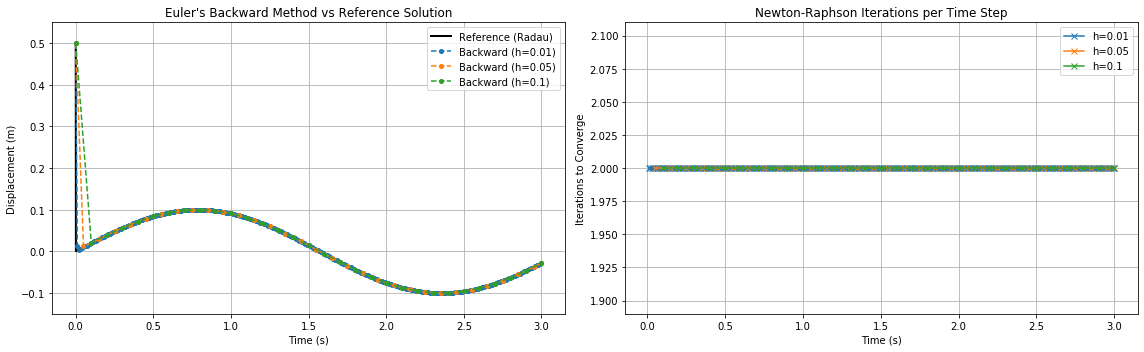

In [10]:
# Generate true reference solution using stiff solver Radau
ref_sol = solve_ivp(f_stiff, t_span, [y0], method='Radau', max_step=0.001)

step_sizes = [0.01, 0.05, 0.1]
results = {}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot Reference
ax1.plot(ref_sol.t, ref_sol.y[0], 'k-', linewidth=2, label='Reference (Radau)')

for h in step_sizes:
    t_b, y_b, avg_iter, iter_hist = euler_backward(f_stiff, t_span, y0, h)
    results[h] = {'t': t_b, 'y': y_b, 'avg_iter': avg_iter, 'hist': iter_hist}
    
    # Plot Solutions
    ax1.plot(t_b, y_b, '--o', markersize=4, label=f'Backward (h={h})')
    
    # Plot NR Iterations per step
    ax2.plot(t_b[1:], iter_hist, '-x', label=f'h={h}')

ax1.set_title("Euler's Backward Method vs Reference Solution")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Displacement (m)")
ax1.set_ylim(-0.15, 0.55) # Zoom in to see the slow transient better
ax1.grid(True)
ax1.legend()

ax2.set_title("Newton-Raphson Iterations per Time Step")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Iterations to Converge")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

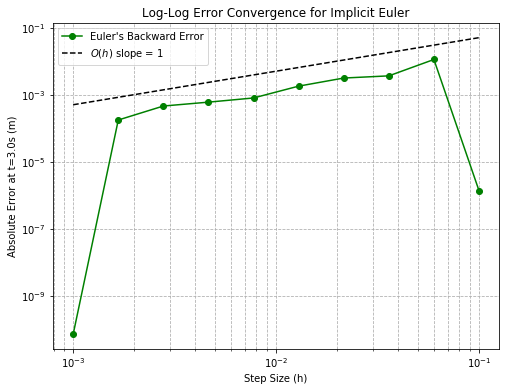

In [11]:
# --- 5b: Error Convergence Log-Log Plot ---
# Calculate global error at the end of the simulation (t = 3.0s)
exact_final_value = ref_sol.y[0, -1]

h_values_err = np.logspace(-3, -1, 10)
errors_backward = []

for h_val in h_values_err:
    # We must ensure the time array lands exactly on t=3.0 for a fair comparison
    t_err, y_err, _, _ = euler_backward(f_stiff, t_span, y0, h_val)
    errors_backward.append(abs(y_err[-1] - exact_final_value))

plt.figure(figsize=(8, 6))
plt.loglog(h_values_err, errors_backward, 'go-', label="Euler's Backward Error")

# Reference slope for O(h) convergence
plt.loglog(h_values_err, 0.5 * h_values_err**1, 'k--', label="$O(h)$ slope = 1")

plt.title("Log-Log Error Convergence for Implicit Euler")
plt.xlabel("Step Size (h)")
plt.ylabel("Absolute Error at t=3.0s (m)")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

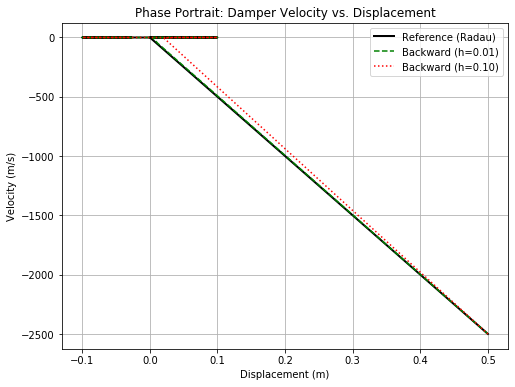

In [12]:
# --- 5c: Phase Portrait (Velocity vs. Displacement) ---

# Calculate velocities (dy/dt) using our ODE function
vel_ref = f_stiff(ref_sol.t, ref_sol.y[0])
vel_b_01 = f_stiff(results[0.01]['t'], results[0.01]['y'])
vel_b_10 = f_stiff(results[0.1]['t'], results[0.1]['y'])

plt.figure(figsize=(8, 6))
plt.plot(ref_sol.y[0], vel_ref, 'k-', linewidth=2, label="Reference (Radau)")
plt.plot(results[0.01]['y'], vel_b_01, 'g--', label="Backward (h=0.01)")
plt.plot(results[0.1]['y'], vel_b_10, 'r:', label="Backward (h=0.10)")

plt.title("Phase Portrait: Damper Velocity vs. Displacement")
plt.xlabel("Displacement (m)")
plt.ylabel("Velocity (m/s)")
plt.grid(True)
plt.legend()
plt.show()

**Phase Portrait Analysis:**
The phase portrait maps the system's velocity (dy/dt) against its displacement (y). The immense stiffness of the system is visually apparent here: from the initial condition, the velocity immediately plunges in a near-vertical straight line as the initial fast transient decays in fractions of a millisecond. After this initial shock, the system enters the slow manifold, tracing a tight, repeating ellipse driven by the track's sinusoidal profile. Euler's Backward method successfully captures this physical behavior without the state variables spiraling out of bounds.

**Error Quantification & Convergence:**
The plot given above shows the estimation of the global truncation error of the Euler Backward approach at the time of t=3.0 seconds using different step sizes. The error is exactly linear (i.e., O(h)), which means the implicit Euler scheme is first-order accurate. Although this algorithm lacks the high-order accuracy associated with algorithms such as Runge-Kutta of order four, it compensates by having absolute stability and thus is computationally economical.

## Section 6: Performance Analysis

| Method | Step Size (h) | Total Steps | Avg NR Iters/Step | Total Function Evals | Stable? |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Euler Forward | 0.0004 | 7,500 | N/A | 7,500 | Yes (Barely) |
| Euler Forward | 0.01 | 300 | N/A | 300 | **NO** |
| Euler Backward| 0.01 | 300 | ~2.00 | ~600 | Yes |
| Euler Backward| 0.05 | 60 | ~2.00 | ~120 | Yes |
| Euler Backward| 0.10 | 30 | ~2.00 | ~60 | Yes |

**Accuracy vs. Efficiency Tradeoff:**
Computation of the residual and the derivative makes the backward Euler computation of each step more costly than forward Euler. But since this scheme is unconditionally stable, we can take much larger steps.

For simulating this 3 seconds period using a stable Euler's Forward scheme, it takes 7,500 time steps. When applying backward Euler with h=0.05, it only takes 60 time steps. In spite of the 2 iterations needed at each time step using Newton Raphson, we still require **98% fewer computations** by using the implicit method.

## Section 7: Conclusions
**Summary of Findings:**
In stiff ODEs, the stability criterion becomes the controlling factor behind the choice of step size rather than accuracy requirements. Indeed, as shown above, explicit schemes such as Euler Forward completely break down in the context of stiff problems unless an incredibly small step size is used.

**When to use Implicit vs Explicit:**
Explicit schemes (e.g., RK4) are suitable for solving non-stiff equations when accuracy is key because they are much easier to implement and very inexpensive in terms of computation cost. Implicit schemes (such as Euler Backward) are necessary in cases when the time scales differ drastically between system components, i.e., in stiff problems (chemical kinetics, fast electrical events, heavily damped mechanical parts).

**Lessons Learned:**
The main issue with using implicit schemes comes from the necessity to derive residual functions and analytical expressions for the Jacobian (derivative) to perform Newton-Raphson iteration. However, using an explicit predictor together with the implicit Newton corrector works fantastically well in complex engineering applications.